In [1]:
import sys
import pandas as pd
sys.path.append('../lib')
#Note: When working in Windows environments, use:
#sys.path.append('..\lib')
from library import Library
from sample import Sample
import seaborn as sns
color = sns.color_palette()

%matplotlib inline

In [2]:
import urllib.request, json

url = "https://htem-api.nrel.gov/api/sample_library"
response = urllib.request.urlopen(url)
data = json.loads(response.read().decode())

In [3]:
num_params = {}
for library in data:
    if len(library) not in num_params:
        num_params[len(library)] = 0
    num_params[len(library)] += 1
print(num_params)

{21: 1891}


In [4]:
len(data)

1891

In [5]:
# We are looking for ids with: has_xrd != 0, has_xrf != 0, deposition_[parameter] != null
# Total deposition parameters = 9

xrd_xrf_deposition_lib_ids = {}

def checkAtLeastOneNonNull(arr):
    if len(arr) == 0: return False
    for val in arr:
        if val is not None:
            return True
    return False

for entry in data:
    if entry["has_xrd"] != 0 and entry["has_xrf"] != 0:
        # if lib_id["has_xrd"] != lib_id["has_xrf"]:
        #     print(lib_id["id"])
            
        non_null_deposition = 0 
        for key in entry:
            if "deposition" in key:
                if (isinstance(entry[key], list) and checkAtLeastOneNonNull(entry[key])) or (not isinstance(entry[key], list) and entry[key] is not None):
                    non_null_deposition += 1
        if non_null_deposition not in xrd_xrf_deposition_lib_ids:
            xrd_xrf_deposition_lib_ids[non_null_deposition] = []
        xrd_xrf_deposition_lib_ids[non_null_deposition].append(entry["id"])

for i in sorted(xrd_xrf_deposition_lib_ids.keys(), reverse=True):
    print(i, len(xrd_xrf_deposition_lib_ids[i]))

8 421
7 118
6 1
5 57
4 117
3 75
2 48
1 2
0 67


In [6]:
# No ids with all 9 deposition parameters, investigate ones with 8 parameters (highest found)
# Find librarys with thickness parameters in samples

thickness_library_ids = {}
library_sample_error_ids = []
library_error_ids = []
currentLibrary = 0
xr_deposition_lib_ids = xrd_xrf_deposition_lib_ids[8]

for lib_id in xr_deposition_lib_ids:
    currentLibrary += 1
    
    try:
        url = "https://htem-api.nrel.gov/api/sample_library/" + str(lib_id)
        response = urllib.request.urlopen(url)
        library = json.loads(response.read().decode())
        numValidSamples = 0
    
        if "sample_ids" not in library or len(library["sample_ids"]) == 0:
            print(f"Library: {lib_id} SKIPPED ({currentLibrary/len(xr_deposition_lib_ids) * 100}%)")
            continue
    
        # currentSample = 1
        # totalSamples = len(library["sample_ids"])
        
        for sample_id in library["sample_ids"]:
            try:
                url = "https://htem-api.nrel.gov/api/sample/" + str(sample_id)
                response = urllib.request.urlopen(url)
                sample = json.loads(response.read().decode())
    
                if sample["thickness"] != None:
                    numValidSamples += 1
                    
                # if currentLibrary <= 3 and (currentSample % 10 == 0 or currentSample == totalSamples or currentSample == 1):
                #     print(f"Library: {library["id"]} ({currentSample}/{totalSamples})")
            except Exception as ex:
                library_sample_error_ids.append((lib_id, sample_id))
                print(f"Library: {lib_id} - Sample #{sample_id} Error")
    
            # currentSample += 1
                
        if numValidSamples not in thickness_library_ids:
            thickness_library_ids[numValidSamples] = []
        thickness_library_ids[numValidSamples].append(lib_id)
    
        print(f"Library: {lib_id} COMPLETE ({round(currentLibrary/len(xr_deposition_lib_ids) * 100, 2)}%)")
    except Exception as ex:
        print(f"Library: {lib_id} ACCESS ERROR ({round(currentLibrary/len(xr_deposition_lib_ids) * 100, 2)}%)")

Library: 6707 COMPLETE (0.24%)
Library: 6938 COMPLETE (0.48%)
Library: 7131 COMPLETE (0.71%)
Library: 7317 COMPLETE (0.95%)
Library: 7335 COMPLETE (1.19%)
Library: 9966 COMPLETE (1.43%)
Library: 10302 COMPLETE (1.66%)
Library: 12802 COMPLETE (1.9%)
Library: 12583 - Sample #387123 Error
Library: 12583 - Sample #387124 Error
Library: 12583 - Sample #387125 Error
Library: 12583 - Sample #387126 Error
Library: 12583 - Sample #387127 Error
Library: 12583 - Sample #387128 Error
Library: 12583 - Sample #387129 Error
Library: 12583 - Sample #387130 Error
Library: 12583 - Sample #387131 Error
Library: 12583 - Sample #387132 Error
Library: 12583 - Sample #387133 Error
Library: 12583 - Sample #387135 Error
Library: 12583 - Sample #387136 Error
Library: 12583 - Sample #387137 Error
Library: 12583 - Sample #387138 Error
Library: 12583 - Sample #387139 Error
Library: 12583 - Sample #387140 Error
Library: 12583 - Sample #387141 Error
Library: 12583 - Sample #387142 Error
Library: 12583 - Sample #3871

In [7]:
for i in sorted(thickness_library_ids.keys(), reverse=True):
    print(i, len(thickness_library_ids[i]))

44 400
43 3
31 1
30 1
17 1
12 1
11 2
10 1
7 2
6 2
4 1
2 2
1 4


In [8]:
# Some libraries have all 44 samples with xrd, xrf, and thickness and 8/9 process parameters
# Need to investigate 3 additional process parameters
all_thickness_library_ids = thickness_library_ids[44]

In [9]:
len(all_thickness_library_ids)

400

In [10]:
all_thickness_library_ids

[6707,
 6938,
 7131,
 7317,
 7335,
 9966,
 10302,
 12802,
 12585,
 12587,
 12589,
 12605,
 12607,
 12803,
 12804,
 12805,
 12806,
 6863,
 6870,
 6912,
 7069,
 7079,
 7083,
 7318,
 9858,
 12590,
 11916,
 7541,
 10904,
 9940,
 10891,
 7242,
 10936,
 7461,
 10058,
 10874,
 11915,
 7536,
 6695,
 12606,
 6706,
 6783,
 6677,
 6728,
 6732,
 6851,
 6852,
 6854,
 6914,
 6999,
 7060,
 7117,
 7136,
 7139,
 7173,
 7174,
 7333,
 7548,
 7371,
 7458,
 7465,
 7483,
 7507,
 7520,
 7524,
 7528,
 7898,
 8470,
 8471,
 9766,
 9778,
 9808,
 9969,
 9973,
 9981,
 10047,
 10126,
 10368,
 10455,
 11042,
 11901,
 11903,
 11904,
 6678,
 6679,
 6680,
 6685,
 6691,
 6693,
 6713,
 6738,
 6765,
 6779,
 6782,
 6790,
 6807,
 6811,
 6880,
 6895,
 6904,
 6934,
 6961,
 6963,
 7030,
 6974,
 6985,
 7016,
 7045,
 7064,
 7095,
 7116,
 7118,
 7151,
 7153,
 7172,
 7181,
 7182,
 7241,
 7250,
 7263,
 7296,
 7320,
 7338,
 7345,
 7361,
 7404,
 7412,
 7426,
 7446,
 7449,
 7494,
 7576,
 7899,
 8322,
 8335,
 8336,
 8337,
 8338,
 8551,

In [11]:
lib_ids_with_xrf = {}
for entry in data:
    lib_id = entry["id"]
    if lib_id in all_thickness_library_ids:
        if entry["has_xrf"] != 0:
            if entry["has_xrf"] not in lib_ids_with_xrf:
                lib_ids_with_xrf[entry["has_xrf"]] = []
            lib_ids_with_xrf[entry["has_xrf"]].append(lib_id)
            
for i in sorted(lib_ids_with_xrf.keys(), reverse=True):
    print(i, len(lib_ids_with_xrf[i]))  

# It appears all of the current 398 libraries also have all 44 xrf values in their samples

44 400


In [12]:
# Finally, check how many libraries have process parameters within the library view in the hierarchy (3 more than the inital 9)
lib_ids_xrf = lib_ids_with_xrf[44]

# Partial may contain arrays such as [5, 10, null]
# Full only contains arrays with non null values [5, 10, 15]
ids_partial_non_null = {}
ids_full_non_null = {}

currentLibrary = 0
totalLibraries = len(lib_ids_xrf)

for lib_id in lib_ids_xrf:
    url = "https://htem-api.nrel.gov/api/sample_library/" + str(lib_id)
    response = urllib.request.urlopen(url)
    library = json.loads(response.read().decode())

    partial_non_null_deposition = 0
    full_non_null_deposition = 0
    
    for key in library:
        if "deposition" in key:
            value = library[key]

            if not isinstance(value, list):
                if value is not None:
                    partial_non_null_deposition += 1
                    full_non_null_deposition += 1
            else:
                # value is a list
                if value and value[0] is not None:
                    partial_non_null_deposition += 1
                if value and all(i is not None for i in value):
                    full_non_null_deposition += 1
            
    if partial_non_null_deposition not in ids_partial_non_null:
        ids_partial_non_null[partial_non_null_deposition] = []
    ids_partial_non_null[partial_non_null_deposition].append(lib_id)

    if full_non_null_deposition not in ids_full_non_null:
        ids_full_non_null[full_non_null_deposition] = []
    ids_full_non_null[full_non_null_deposition].append(lib_id)
    
    currentLibrary += 1
    print(f"Library {lib_id} COMPLETE ({round(currentLibrary/totalLibraries * 100, 2)}%)")

Library 6707 COMPLETE (0.25%)
Library 6938 COMPLETE (0.5%)
Library 7131 COMPLETE (0.75%)
Library 7317 COMPLETE (1.0%)
Library 7335 COMPLETE (1.25%)
Library 9966 COMPLETE (1.5%)
Library 10302 COMPLETE (1.75%)
Library 12802 COMPLETE (2.0%)
Library 12585 COMPLETE (2.25%)
Library 12587 COMPLETE (2.5%)
Library 12589 COMPLETE (2.75%)
Library 12605 COMPLETE (3.0%)
Library 12607 COMPLETE (3.25%)
Library 12803 COMPLETE (3.5%)
Library 12804 COMPLETE (3.75%)
Library 12805 COMPLETE (4.0%)
Library 12806 COMPLETE (4.25%)
Library 6863 COMPLETE (4.5%)
Library 6870 COMPLETE (4.75%)
Library 6912 COMPLETE (5.0%)
Library 7069 COMPLETE (5.25%)
Library 7079 COMPLETE (5.5%)
Library 7083 COMPLETE (5.75%)
Library 7318 COMPLETE (6.0%)
Library 9858 COMPLETE (6.25%)
Library 12590 COMPLETE (6.5%)
Library 11916 COMPLETE (6.75%)
Library 7541 COMPLETE (7.0%)
Library 10904 COMPLETE (7.25%)
Library 9940 COMPLETE (7.5%)
Library 10891 COMPLETE (7.75%)
Library 7242 COMPLETE (8.0%)
Library 10936 COMPLETE (8.25%)
Library 74

In [13]:
for i in sorted(ids_partial_non_null.keys(), reverse=True):
    print(i, len(ids_partial_non_null[i]))

print()

for i in sorted(ids_full_non_null.keys(), reverse=True):
    print(i, len(ids_full_non_null[i]))

9 383
8 17

9 8
7 224
6 53
5 111
4 4


In [14]:
# Final library ids with: 44 xrd measurements, 44 xrf measurements, 44 thicknesses, and ...

# 9/12 process parameters with at least 1 non null value (383 libraries)
partial_final_lib_ids = ids_partial_non_null[9]

# 7/12 process parameters with no null values (224 libraries)
full_final_lib_ids = ids_full_non_null[7]

In [15]:
# With these ids, we want to relate the libraries to see if a dominant element pairing emerges to create a merged dataset

# Perform similar element analysis to initial screening on partial final ids
import urllib.request, json

url = "https://htem-api.nrel.gov/api/sample_library"
response = urllib.request.urlopen(url)
data = json.loads(response.read().decode())

all_elements = set()
for entry in data:
    if entry["id"] in partial_final_lib_ids:
        all_elements.update(entry.get("elements", []))
all_elements = sorted(all_elements)

In [16]:
rows = []
for entry in data:
    if entry["id"] in partial_final_lib_ids:
        row = {"id": entry["id"]}
        present_elements = set(entry.get("elements", []))
        
        # Mark 1 if element is in the library, 0 if not
        for element in all_elements:
            row[element] = 1 if element in present_elements else 0
        
        rows.append(row)

In [17]:
df_elements = pd.DataFrame(rows, columns=["id"] + all_elements)
df_elements.sort_values(by="id").reset_index(drop=True)

,id,Ag,Co,Cr,Cu,Fe,Ga,Ge,H,In,...,N,Ni,O,Sb,Sn,Ta,Ti,V,W,Zn
0,6626,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,6630,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
2,6632,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,6639,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,6648,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,12802,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,1
379,12803,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,1
380,12804,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,1
381,12805,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,1


In [18]:
import matplotlib.pyplot as plt

In [19]:
element_counts = df_elements.drop(columns="id").sum()

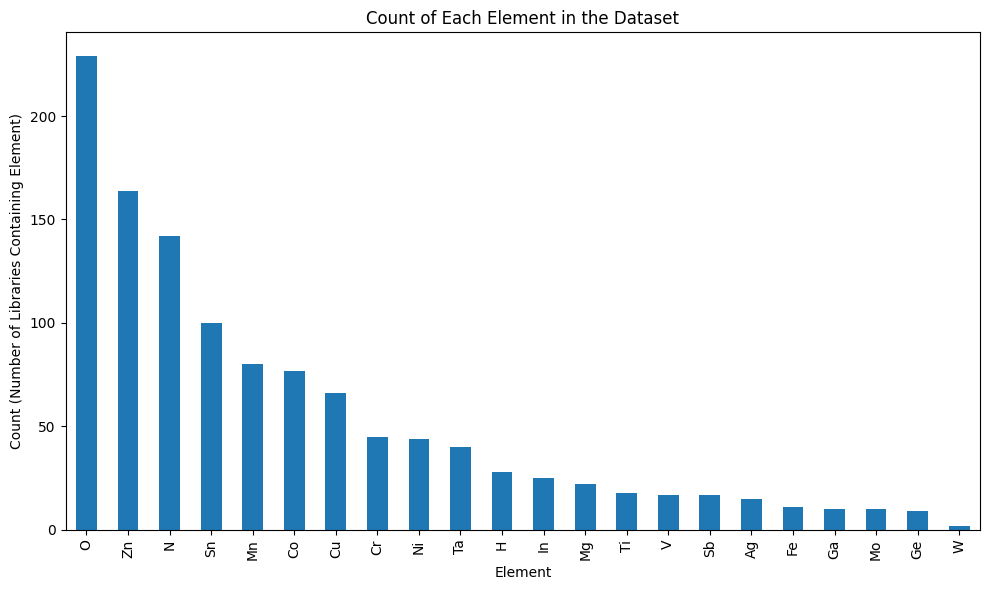

In [20]:
plt.figure(figsize=(10, 6))
element_counts.sort_values(ascending=False).plot(kind="bar")
plt.title("Count of Each Element in the Dataset")
plt.xlabel("Element")
plt.ylabel("Count (Number of Libraries Containing Element)")
plt.tight_layout()
plt.show()

In [21]:
element_groups = {}
for entry in data:
    if entry["id"] in partial_final_lib_ids:
        if tuple(entry["elements"]) not in element_groups: element_groups[tuple(entry["elements"])] = 0
        element_groups[tuple(entry["elements"])] += 1

element_groups = sorted(
    element_groups.items(),
    key=lambda x: (-x[1], -len(x[0]), x[0])
)

element_groups

[(('Zn', 'Sn', 'N'), 28),
 (('Cu', 'N'), 28),
 (('Mn', 'O', 'Sn'), 23),
 (('Mn', 'O', 'Cr'), 22),
 (('Ta', 'Sn', 'Co'), 19),
 (('Ta', 'Cu', 'N'), 15),
 (('Zn', 'O', 'Co', 'Ni'), 14),
 (('V', 'Ag', 'O'), 14),
 (('Ti', 'O', 'Zn', 'H'), 13),
 (('Zn', 'Ge', 'N'), 9),
 (('Zn', 'O', 'Co'), 9),
 (('Zn', 'Sb', 'N'), 9),
 (('Fe', 'O', 'In'), 8),
 (('Ni', 'O', 'Co'), 8),
 (('Zn', 'Mo', 'N'), 8),
 (('Sb', 'Zn', 'N'), 7),
 (('Ni', 'O', 'Co', 'Zn'), 6),
 (('Zn', 'O', 'Ni', 'Co'), 6),
 (('Cr', 'O', 'Mg'), 6),
 (('Mn', 'O', 'In'), 6),
 (('Mn', 'O'), 6),
 (('Mn', 'O', 'Cr', 'Mg'), 5),
 (('Mn', 'O', 'In', 'H'), 5),
 (('Sn', 'O', 'Zn', 'Ti'), 5),
 (('Co', 'O', 'Zn'), 5),
 (('Cu', 'Zn', 'N'), 5),
 (('Ga', 'O', 'Zn', 'H'), 4),
 (('Mn', 'O', 'Sn', 'H'), 4),
 (('Sn', 'O', 'In', 'Zn'), 4),
 (('Cu', 'O', 'N'), 4),
 (('Cu', 'Sn', 'N'), 4),
 (('Ga', 'O', 'Zn'), 4),
 (('Mg', 'O', 'Zn'), 4),
 (('Cu', 'O'), 4),
 (('Ni', 'O'), 4),
 (('Ta', 'N'), 4),
 (('Mn', 'O', 'Cr', 'N'), 3),
 (('Cu', 'O', 'Zn'), 3),
 (('Zn', 'S

In [22]:
most_frequent_pairing = element_groups[0][0]
single_system_lib_ids = []

for entry in data:
    if entry["id"] in partial_final_lib_ids:
        if tuple(entry["elements"]) == most_frequent_pairing:
            single_system_lib_ids.append(entry["id"])

print(most_frequent_pairing)
print(len(single_system_lib_ids))
single_system_lib_ids

('Zn', 'Sn', 'N')
28


[9966,
 10302,
 9858,
 10058,
 9766,
 10047,
 10028,
 10060,
 9990,
 6856,
 7073,
 8622,
 8626,
 6975,
 6648,
 6971,
 7002,
 7287,
 7464,
 6768,
 6944,
 7342,
 9814,
 7771,
 7417,
 7031,
 7857,
 7708]

Repeat with the full_final_lib_ids data

In [23]:
all_elements = set()
for entry in data:
    if entry["id"] in full_final_lib_ids:
        all_elements.update(entry.get("elements", []))
all_elements = sorted(all_elements)

In [24]:
rows = []
for entry in data:
    if entry["id"] in partial_final_lib_ids:
        row = {"id": entry["id"]}
        present_elements = set(entry.get("elements", []))
        
        # Mark 1 if element is in the library, 0 if not
        for element in all_elements:
            row[element] = 1 if element in present_elements else 0
        
        rows.append(row)

In [25]:
df_elements = pd.DataFrame(rows, columns=["id"] + all_elements)
df_elements.sort_values(by="id").reset_index(drop=True)

,id,Co,Cr,Cu,Ga,Ge,H,In,Mg,Mn,Mo,N,Ni,O,Sn,Ta,Ti,V,W,Zn
0,6626,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
1,6630,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1
2,6632,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
3,6639,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
4,6648,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,12802,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
379,12803,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
380,12804,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
381,12805,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


In [26]:
element_counts = df_elements.drop(columns="id").sum()

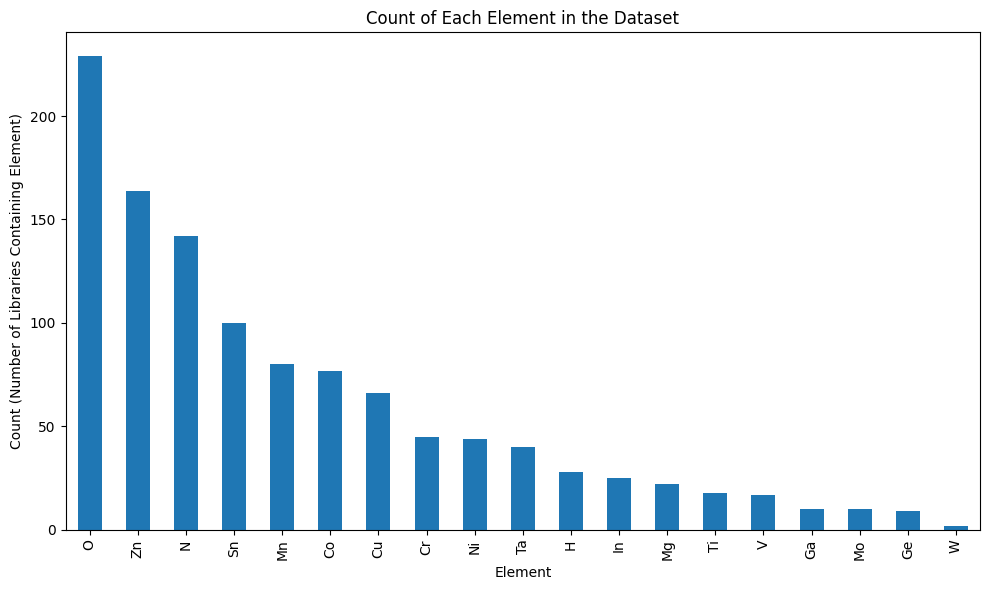

In [27]:
plt.figure(figsize=(10, 6))
element_counts.sort_values(ascending=False).plot(kind="bar")
plt.title("Count of Each Element in the Dataset")
plt.xlabel("Element")
plt.ylabel("Count (Number of Libraries Containing Element)")
plt.tight_layout()
plt.show()

In [28]:
element_groups = {}
for entry in data:
    if entry["id"] in full_final_lib_ids:
        if tuple(entry["elements"]) not in element_groups: element_groups[tuple(entry["elements"])] = 0
        element_groups[tuple(entry["elements"])] += 1

element_groups = sorted(
    element_groups.items(),
    key=lambda x: (-x[1], -len(x[0]), x[0])
)

element_groups

[(('Mn', 'O', 'Sn'), 23),
 (('Zn', 'Sn', 'N'), 21),
 (('Ta', 'Sn', 'Co'), 19),
 (('Mn', 'O', 'Cr'), 18),
 (('Zn', 'O', 'Co', 'Ni'), 14),
 (('Ti', 'O', 'Zn', 'H'), 13),
 (('Cu', 'N'), 10),
 (('Ni', 'O', 'Co'), 7),
 (('Ni', 'O', 'Co', 'Zn'), 6),
 (('Zn', 'O', 'Ni', 'Co'), 6),
 (('Mn', 'O', 'In'), 6),
 (('Mn', 'O'), 6),
 (('Mn', 'O', 'In', 'H'), 5),
 (('Sn', 'O', 'Zn', 'Ti'), 5),
 (('Cr', 'O', 'Mg'), 5),
 (('Mn', 'O', 'Sn', 'H'), 4),
 (('Sn', 'O', 'In', 'Zn'), 4),
 (('Co', 'O', 'Zn'), 4),
 (('Ga', 'O', 'Zn'), 4),
 (('Mg', 'O', 'Zn'), 4),
 (('Mn', 'O', 'Cr', 'N'), 3),
 (('Cu', 'O', 'Zn'), 3),
 (('Ta', 'Cu', 'N'), 3),
 (('Zn', 'Ge', 'N'), 3),
 (('Cr', 'O', 'Mg', 'N'), 2),
 (('Mn', 'O', 'Cr', 'H'), 2),
 (('Co', 'O', 'Ni'), 2),
 (('Cu', 'O', 'N'), 2),
 (('Cu', 'Ta', 'N'), 2),
 (('V', 'Sn', 'Co'), 2),
 (('Ta', 'N'), 2),
 (('Cr', 'Mn', 'O', 'N'), 1),
 (('Cu', 'Zn', 'Co', 'N'), 1),
 (('Mg', 'O', 'Zn', 'Ga'), 1),
 (('Mo', 'W', 'Zn', 'N'), 1),
 (('Ni', 'O', 'Zn', 'Co'), 1),
 (('Zn', 'O', 'In', 'Sn

In [29]:
most_frequent_pairing = element_groups[0][0]
single_system_lib_ids = []

for entry in data:
    if entry["id"] in full_final_lib_ids:
        if tuple(entry["elements"]) == most_frequent_pairing:
            single_system_lib_ids.append(entry["id"])

print(most_frequent_pairing)
print(len(single_system_lib_ids))
single_system_lib_ids

('Mn', 'O', 'Sn')
23


[8438,
 8449,
 8452,
 8454,
 8455,
 8457,
 8458,
 8366,
 8367,
 8374,
 8431,
 8432,
 8433,
 8434,
 8435,
 8436,
 8450,
 8453,
 8456,
 10256,
 8451,
 8448,
 8437]

In [31]:
partial_final_lib_ids

[6707,
 6938,
 7131,
 7317,
 9966,
 10302,
 12802,
 12585,
 12587,
 12589,
 12607,
 12803,
 12804,
 12805,
 12806,
 6863,
 6870,
 6912,
 7069,
 7079,
 7083,
 7318,
 9858,
 11916,
 7541,
 10904,
 9940,
 10891,
 7242,
 10936,
 7461,
 10058,
 11915,
 7536,
 6695,
 12606,
 6706,
 6783,
 6677,
 6728,
 6732,
 6851,
 6852,
 6854,
 6914,
 6999,
 7060,
 7117,
 7136,
 7139,
 7174,
 7333,
 7548,
 7458,
 7483,
 7507,
 7520,
 7524,
 7528,
 7898,
 8470,
 8471,
 9766,
 9778,
 9808,
 9969,
 9973,
 9981,
 10047,
 10126,
 10368,
 10455,
 11042,
 11901,
 6678,
 6679,
 6680,
 6685,
 6691,
 6693,
 6713,
 6738,
 6765,
 6779,
 6782,
 6790,
 6807,
 6811,
 6880,
 6895,
 6904,
 6934,
 6961,
 6963,
 7030,
 6974,
 6985,
 7016,
 7045,
 7064,
 7095,
 7116,
 7118,
 7151,
 7153,
 7172,
 7181,
 7182,
 7241,
 7250,
 7263,
 7296,
 7320,
 7338,
 7345,
 7361,
 7404,
 7412,
 7426,
 7446,
 7449,
 7494,
 7576,
 7899,
 8322,
 8335,
 8336,
 8337,
 8338,
 8551,
 9779,
 9980,
 10001,
 10104,
 10107,
 10114,
 10116,
 10137,
 1046

In [32]:
full_final_lib_ids

[9966,
 12585,
 12589,
 6863,
 6870,
 6912,
 7069,
 7079,
 7083,
 9858,
 7541,
 10904,
 9940,
 7242,
 10936,
 7461,
 7536,
 12606,
 6706,
 6677,
 6728,
 6851,
 6852,
 6914,
 6999,
 7060,
 7117,
 7139,
 7174,
 7333,
 7548,
 7520,
 7524,
 7528,
 9969,
 9973,
 6678,
 6679,
 6691,
 6693,
 6738,
 6782,
 6790,
 6811,
 6880,
 6904,
 6934,
 6963,
 6985,
 7045,
 7095,
 7116,
 7118,
 7153,
 7172,
 7181,
 7182,
 7338,
 7345,
 7361,
 7412,
 7446,
 7449,
 7494,
 7899,
 8335,
 8336,
 8337,
 8338,
 8551,
 10104,
 10107,
 10137,
 6658,
 6684,
 7532,
 7542,
 7150,
 10136,
 7564,
 9764,
 7204,
 7529,
 6940,
 6651,
 7540,
 6923,
 6931,
 9777,
 6876,
 6701,
 7521,
 7123,
 10105,
 7551,
 7533,
 7188,
 6710,
 7113,
 10106,
 7516,
 7360,
 7523,
 7561,
 7243,
 6995,
 7505,
 8390,
 8398,
 8399,
 8405,
 8438,
 8449,
 8452,
 8454,
 8455,
 8457,
 8458,
 8464,
 8466,
 8467,
 8469,
 8526,
 10248,
 6796,
 7075,
 7082,
 7310,
 7325,
 7463,
 7486,
 8366,
 8367,
 8368,
 8369,
 8374,
 8375,
 8376,
 8377,
 8378,
 8381,
 

For the IDs with 9/12 process parameters that are not null or have arrays with at least the first element not null, the dominant system is the ('Zn', 'Sn', 'N') with 28 libraries.
For the IDs with 7/12 process parameters all not null even within arrays, the system is ('Mn', 'O', 'Sn') with 23 libraries.